In [13]:
%matplotlib inline
import random
import torch
from d2l import torch as d2l

In [14]:
# 1. 生成数据集
def synthetic_data(w, b, num_examples):  #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w)))  # 1000 x 2
    y = torch.matmul(X, w) + b   # 1000 x 1
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))  # 1000 x 2, 1000 x 1

true_w = torch.tensor([2, -3.4])  # 1 x 2
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)  # features相当于真实的X, labels相当于真实的y
# 这几行代码，相当于我们扮演了“上帝”，用 true_w 和 true_b 人为捏造了 1000 套房子的信息（features）和成交价（labels）。

In [15]:
true_w

tensor([ 2.0000, -3.4000])

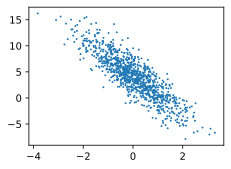

In [17]:
d2l.set_figsize()
d2l.plt.scatter(features[:,(1)].detach().numpy(), labels.detach().numpy(), 1)

In [27]:
# 2. 读取数据集
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]   # 取的是batch_indices中那些行所有列

In [28]:
# 3. 初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True) # 定义了张量的形状（shape）。这里表示创建一个长度为 1 的一维张量。
"""
requires_grad=True（最核心的部分）
requires_grad 的意思是“需要梯度”。
在深度学习中，模型是通过不断计算误差（Loss）对参数的梯度（导数），然后更新参数来学习的（也就是反向传播算法）。
默认情况下，PyTorch 创建的张量 requires_grad=False（不追踪计算过程，为了节省内存和算力）。
当你设置为 True 时，你实际上是在告诉 PyTorch：“这是一个可以训练的参数，请你帮我记录下所有用到它参与的数学运算，以便稍后我可以使用 .backward() 自动计算它的导数。”
"""

In [29]:
w

tensor([[-0.0051],
        [ 0.0069]], requires_grad=True)

In [30]:
b

tensor([0.], requires_grad=True)

In [31]:
# 4. 定义模型
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b

In [32]:
# 5. 定义损失函数
def squared_loss(y_hat, y):
    """均方损失"""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

In [34]:
def sgd(params, lr, batch_size):  #@save
    """小批量随机梯度下降"""
    with torch.no_grad():
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_()

In [36]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
batch_size = 10
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失, 这是前向传播(forward)
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()  # .backward就是自动求w以及b的梯度
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数w和b
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.036620
epoch 2, loss 0.000132
epoch 3, loss 0.000050


In [37]:
print(f'w的估计误差: {true_w - w.reshape(true_w.shape)}')
print(f'b的估计误差: {true_b - b}')

w的估计误差: tensor([-0.0001,  0.0004], grad_fn=<SubBackward0>)
b的估计误差: tensor([0.0005], grad_fn=<RsubBackward1>)
